# Starting-guess model checks for the MBI shared-prior MCMC runs with image_rotator.delta_theta = 0

This notebook plots the starting guess for each wavelength separately while forcing `image_rotator.delta_theta = 0.0` after each scipy-minimize start file is loaded.

For each wavelength it:

- reads the same scipy-minimize start file used by the corresponding MCMC plotting notebook;
- sets the image rotator `delta_theta` value to zero;
- applies the current shared-prior preparation helper, including angle wrapping and boundary nudging;
- prints the starting-guess `inst.logl(...)` value;
- overlays the starting-guess model on the observed double difference and double sum data.


In [1]:
import contextlib
import copy
import io
import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path("/home/rebeccaz/Github/vampires_calibration")
PLOTTING_NOTEBOOK_DIR = REPO_ROOT / "mcmc" / "plotting_notebooks"
MBI_DIR = REPO_ROOT / "mcmc" / "MBI"
CSV_PATH = REPO_ROOT / "data" / "20230914_processed_table.csv"

for path in (REPO_ROOT, MBI_DIR):
    if str(path) not in sys.path:
        sys.path.append(str(path))

import instruments_jax as inst
from shared_priors_with_imr_offset_angles_pm45 import (
    TWOPI,
    build_shared_bounds,
    prepare_p0_for_shared_priors,
)

NOTEBOOK_PATHS = {
    610: PLOTTING_NOTEBOOK_DIR / "610nm_Adjusted_EM_Gain_with_IMR_offset_Angles_PM45_Shared_Priors_20000000_Steps.ipynb",
    670: PLOTTING_NOTEBOOK_DIR / "670nm_Adjusted_EM_Gain_with_IMR_offset_Angles_PM45_Shared_Priors_20000000_Steps.ipynb",
    720: PLOTTING_NOTEBOOK_DIR / "720nm_Adjusted_EM_Gain_with_IMR_offset_Angles_PM45_Shared_Priors_20000000_Steps.ipynb",
    760: PLOTTING_NOTEBOOK_DIR / "760nm_Adjusted_EM_Gain_with_IMR_offset_Angles_PM45_Shared_Priors_20000000_Steps.ipynb",
}

IPOL_EM_GAINS = [1.14, 1.18, 1.18, 1.18]
MBI_EM_GAINS = [1.23, 1.19, 1.2, 1.08]
WAVELENGTH_INDICES = {610: 0, 670: 1, 720: 2, 760: 3}
OBS_MODE = "MBI"

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


def display_table(df, digits=8):
    table = df.copy()
    numeric_cols = table.select_dtypes(include=[np.number]).columns
    table[numeric_cols] = table[numeric_cols].round(digits)
    display(table)


## Helper functions


In [2]:
ASSIGNMENT_RE = re.compile(
    r'^(?P<name>txt_file_path|h5_original_file_path|h5_file_path)\s*=\s*"(?P<value>[^"]+)"',
    re.MULTILINE,
)


def extract_notebook_paths(notebook_path):
    nb = json.loads(notebook_path.read_text())
    code_text = "\n".join(
        "".join(cell.get("source", []))
        for cell in nb["cells"]
        if cell.get("cell_type") == "code"
    )
    paths = {}
    for match in ASSIGNMENT_RE.finditer(code_text):
        paths[match.group("name")] = match.group("value")
    return paths


def get_em_gain(wavelength_nm, obs_mode=OBS_MODE):
    wavelength_index = WAVELENGTH_INDICES[wavelength_nm]
    if obs_mode == "IPOL":
        return IPOL_EM_GAINS[wavelength_index]
    if obs_mode == "MBI":
        return MBI_EM_GAINS[wavelength_index]
    raise ValueError(f"Unknown obs_mode {obs_mode!r}.")


def build_system_dict(em_gain):
    return {
        "components": {
            "wollaston": {
                "type": "wollaston_prism_function",
                "properties": {"beam": "o", "transmission_ratio": em_gain},
            },
            "dichroic": {
                "type": "diattenuator_retarder_function",
                "properties": {"phi": 0, "epsilon": 0, "theta": 0},
            },
            "flc": {
                "type": "general_retarder_function",
                "properties": {"phi": 0.5 * TWOPI, "theta": 0, "delta_theta": 0},
            },
            "optics": {
                "type": "diattenuator_retarder_function",
                "properties": {"phi": 0, "epsilon": 0, "theta": 0},
            },
            "image_rotator": {
                "type": "general_retarder_function",
                "properties": {"phi": 0.5 * TWOPI, "theta": 0, "delta_theta": 0},
            },
            "hwp": {
                "type": "general_retarder_function",
                "properties": {"phi": 0.5 * TWOPI, "theta": 0, "delta_theta": 0},
            },
            "lp": {
                "type": "general_linear_polarizer_function_with_theta",
                "properties": {"theta": 0},
            },
        }
    }


def flatten_p0(p0):
    rows = []
    for component, params in p0.items():
        for parameter, value in params.items():
            rows.append(
                {
                    "component": component,
                    "parameter": parameter,
                    "name": f"{component}.{parameter}",
                    "value": float(value),
                    "value_in_waves": float(value) / TWOPI if parameter == "phi" else np.nan,
                }
            )
    return pd.DataFrame(rows)


def prepare_start_for_wavelength(wavelength_nm):
    notebook_path = NOTEBOOK_PATHS[wavelength_nm]
    paths = extract_notebook_paths(notebook_path)
    txt_file_path = Path(paths["txt_file_path"])

    with txt_file_path.open("r") as f:
        raw_p0 = json.load(f)

    raw_p0.setdefault("image_rotator", {})["delta_theta"] = 0.0

    bounds = build_shared_bounds()
    log_buffer = io.StringIO()
    with contextlib.redirect_stdout(log_buffer):
        p0 = prepare_p0_for_shared_priors(raw_p0, bounds)

    return {
        "wavelength_nm": wavelength_nm,
        "notebook_path": notebook_path,
        "txt_file_path": txt_file_path,
        "raw_p0": raw_p0,
        "p0": p0,
        "preparation_log": log_buffer.getvalue().strip(),
        "em_gain": get_em_gain(wavelength_nm),
    }


def evaluate_starting_guess(wavelength_nm, show_parameter_table=True):
    start_info = prepare_start_for_wavelength(wavelength_nm)
    p0 = start_info["p0"]
    em_gain = start_info["em_gain"]

    system_dict = build_system_dict(em_gain)
    system_mm_for_logl = inst.generate_system_mueller_matrix(copy.deepcopy(system_dict))
    system_mm_for_model = inst.generate_system_mueller_matrix(copy.deepcopy(system_dict))

    interleaved_values, interleaved_stds, configuration_list = inst.read_csv(
        str(CSV_PATH),
        obs_mode=OBS_MODE,
        obs_filter=wavelength_nm,
    )

    p0_values, p0_keywords = inst.parse_configuration(p0)
    s_in = np.array([1, 0, 0, 0])

    logl_value = inst.logl(
        p0_values,
        p0_keywords,
        system_mm_for_logl,
        interleaved_values,
        interleaved_stds,
        configuration_list,
        s_in=s_in,
        logl_function=None,
        process_dataset=inst.process_dataset,
        process_errors=inst.process_errors,
        process_model=inst.process_model,
    )

    model_output = inst.model(
        p0_values,
        p0_keywords,
        system_mm_for_model,
        configuration_list,
        s_in=s_in,
        process_model=inst.process_model,
    )

    print(f"{wavelength_nm} nm")
    print(f"Starting file: {start_info['txt_file_path']}")
    print(f"EM gain: {em_gain}")
    print(f"Starting-guess inst.logl value: {float(logl_value):.6g}")
    if start_info["preparation_log"]:
        print(start_info["preparation_log"])
    else:
        print("No wrapping/nudging was needed.")

    if show_parameter_table:
        display_table(flatten_p0(p0), digits=8)

    inst.plot_data_and_model(
        interleaved_values,
        interleaved_stds,
        model_output,
        configuration_list,
        wavelength=wavelength_nm,
        model_alpha=1.0,
        first_model_alpha=1.0,
    )

    return {
        **start_info,
        "logl_value": float(logl_value),
        "model_output": model_output,
        "configuration_list": configuration_list,
        "interleaved_values": interleaved_values,
        "interleaved_stds": interleaved_stds,
    }


## Plot each starting guess


610 nm
Starting file: /home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/610_with_IMR_offset_pm_1_degree_fixed_EM_gain_with_dichroic_best_fit_old_fit_values.txt
EM gain: 1.23
Starting-guess inst.logl value: 309.301
No wrapping/nudging was needed.


,component,parameter,name,value,value_in_waves
0,dichroic,phi,dichroic.phi,2.709860,0.431288
1,dichroic,epsilon,dichroic.epsilon,0.000003,NaN
2,dichroic,theta,dichroic.theta,18.918866,NaN
3,flc,phi,flc.phi,3.731386,0.593869
4,flc,delta_theta,flc.delta_theta,1.818706,NaN
5,optics,phi,optics.phi,1.850744,0.294555
6,optics,epsilon,optics.epsilon,0.018186,NaN
7,optics,theta,optics.theta,-19.068282,NaN
8,image_rotator,phi,image_rotator.phi,1.398127,0.222519
9,image_rotator,delta_theta,image_rotator.delta_theta,0.000000,NaN


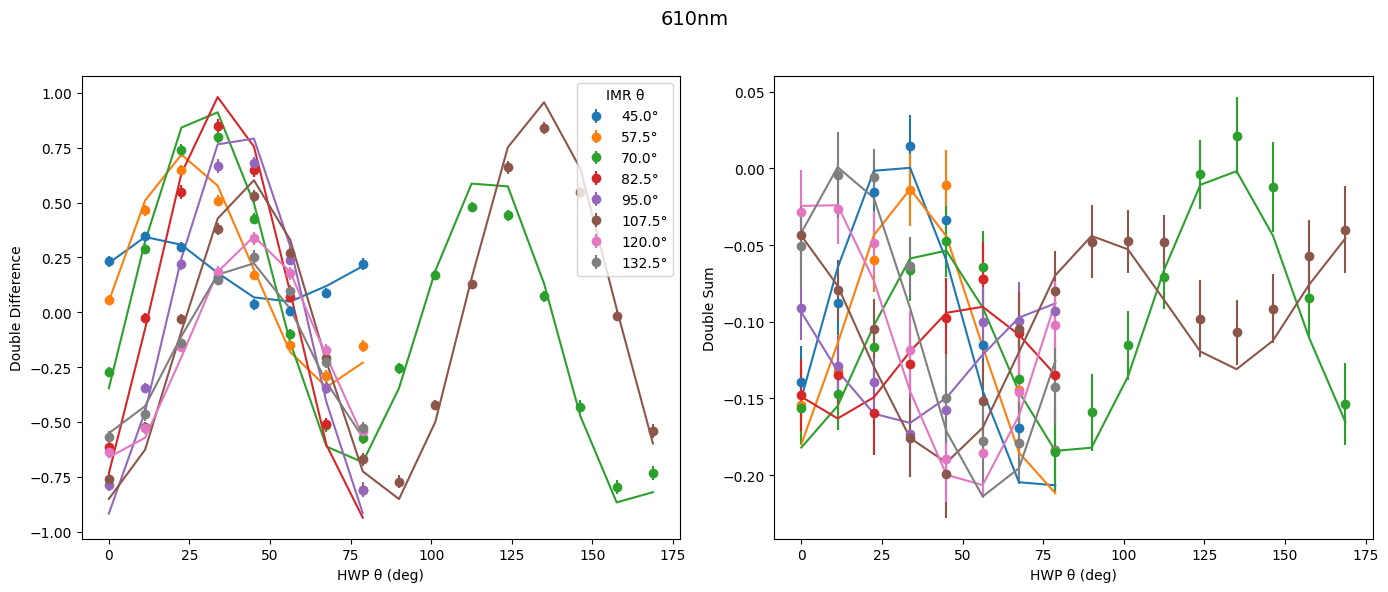

670 nm
Starting file: /home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/670_with_IMR_offset_pm_1_degree_fixed_EM_gain_with_dichroic_best_fit_old_fit_values.txt
EM gain: 1.19
Starting-guess inst.logl value: 138.086
Nudged boundary starting guesses inside shared prior bounds:
  optics.epsilon: 1.8947601e-09 -> 1e-06 within [0, 1]


,component,parameter,name,value,value_in_waves
0,dichroic,phi,dichroic.phi,0.083662,0.013315
1,dichroic,epsilon,dichroic.epsilon,0.287198,NaN
2,dichroic,theta,dichroic.theta,44.935006,NaN
3,flc,phi,flc.phi,3.133748,0.498751
4,flc,delta_theta,flc.delta_theta,0.097712,NaN
5,optics,phi,optics.phi,-0.773107,-0.123044
6,optics,epsilon,optics.epsilon,0.000001,NaN
7,optics,theta,optics.theta,-83.960877,NaN
8,image_rotator,phi,image_rotator.phi,2.003642,0.318890
9,image_rotator,delta_theta,image_rotator.delta_theta,0.000000,NaN


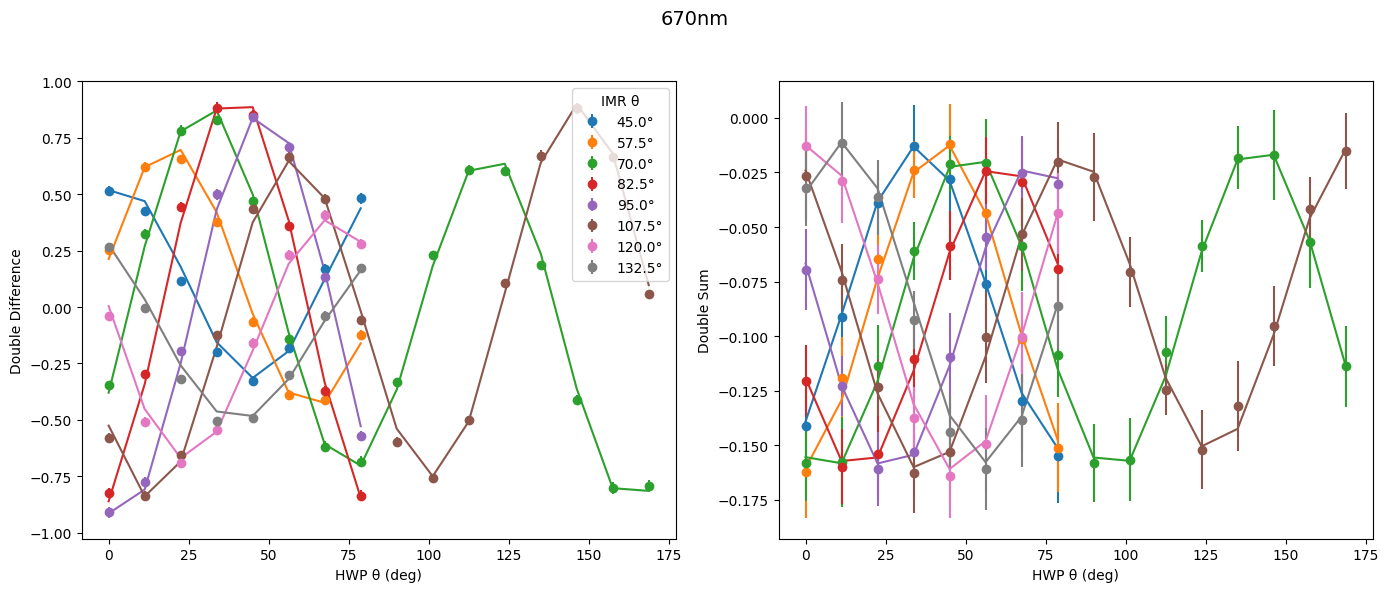

720 nm
Starting file: /home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/720_with_IMR_offset_pm_1_degree_fixed_EM_gain_with_dichroic_best_fit_old_fit_values.txt
EM gain: 1.2
Starting-guess inst.logl value: 627.364
Nudged boundary starting guesses inside shared prior bounds:
  dichroic.epsilon: 6.1918984e-08 -> 1e-06 within [0, 1]


,component,parameter,name,value,value_in_waves
0,dichroic,phi,dichroic.phi,-1.199797,-0.190954
1,dichroic,epsilon,dichroic.epsilon,0.000001,NaN
2,dichroic,theta,dichroic.theta,0.081492,NaN
3,flc,phi,flc.phi,3.231663,0.514335
4,flc,delta_theta,flc.delta_theta,-3.549102,NaN
5,optics,phi,optics.phi,1.267562,0.201739
6,optics,epsilon,optics.epsilon,0.015925,NaN
7,optics,theta,optics.theta,-23.590234,NaN
8,image_rotator,phi,image_rotator.phi,2.993285,0.476396
9,image_rotator,delta_theta,image_rotator.delta_theta,0.000000,NaN


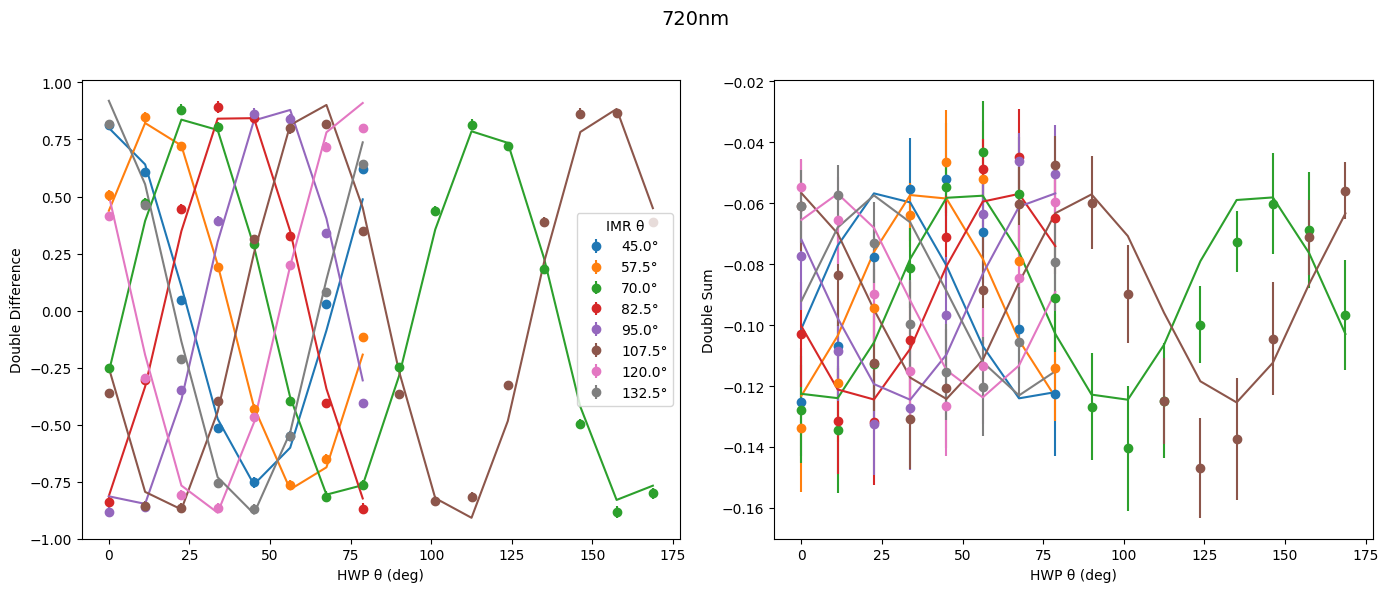

760 nm
Starting file: /home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/760_with_IMR_offset_pm_1_degree_fixed_EM_gain_with_dichroic_best_fit_old_fit_values.txt
EM gain: 1.08
Starting-guess inst.logl value: 407.824
Nudged boundary starting guesses inside shared prior bounds:
  dichroic.epsilon: 4.9626369e-09 -> 1e-06 within [0, 1]


,component,parameter,name,value,value_in_waves
0,dichroic,phi,dichroic.phi,-2.588084,-0.411906
1,dichroic,epsilon,dichroic.epsilon,0.000001,NaN
2,dichroic,theta,dichroic.theta,-13.559062,NaN
3,flc,phi,flc.phi,2.800398,0.445697
4,flc,delta_theta,flc.delta_theta,0.128233,NaN
5,optics,phi,optics.phi,-1.829036,-0.291100
6,optics,epsilon,optics.epsilon,0.167203,NaN
7,optics,theta,optics.theta,-75.986247,NaN
8,image_rotator,phi,image_rotator.phi,3.163588,0.503501
9,image_rotator,delta_theta,image_rotator.delta_theta,0.000000,NaN


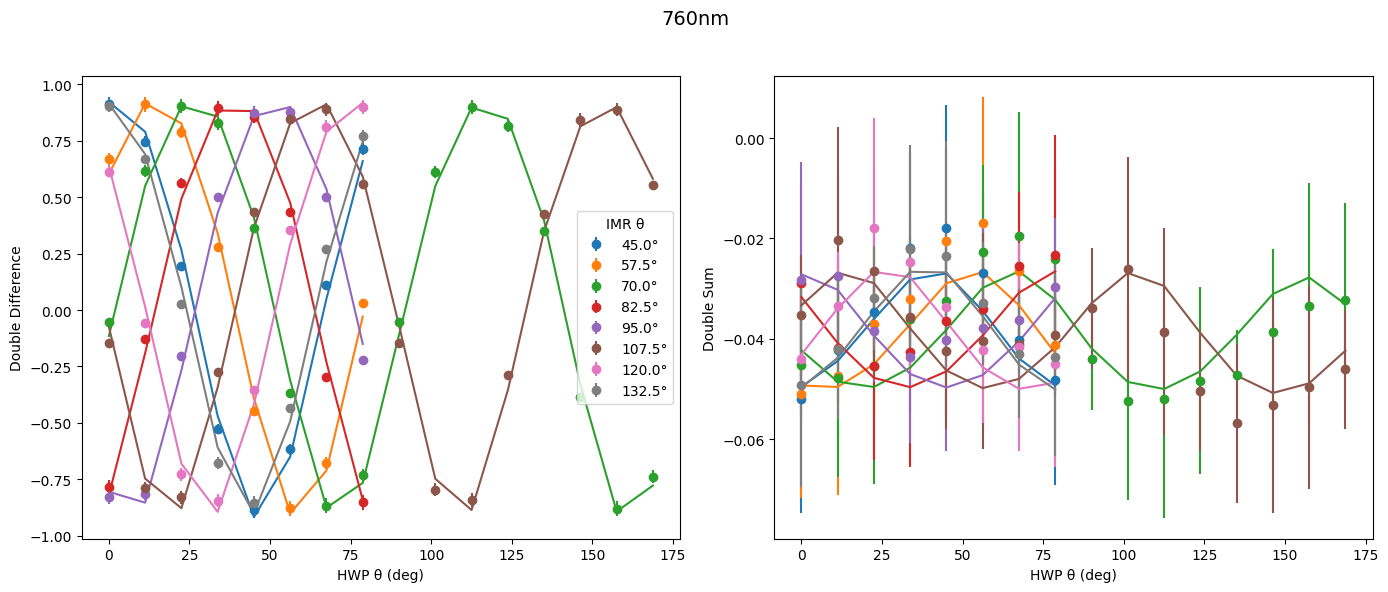

In [3]:
starting_guess_results = {}
for wavelength_nm in NOTEBOOK_PATHS:
    starting_guess_results[wavelength_nm] = evaluate_starting_guess(wavelength_nm)


## Starting-guess objective summary


In [4]:
summary_rows = []
for wavelength_nm, result in starting_guess_results.items():
    summary_rows.append(
        {
            "wavelength_nm": wavelength_nm,
            "logl_value": result["logl_value"],
            "txt_file_path": str(result["txt_file_path"]),
            "em_gain": result["em_gain"],
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("wavelength_nm")
display_table(summary_df)


,wavelength_nm,logl_value,txt_file_path,em_gain
0,610,309.300905,/home/rebeccaz/Github/vampires_calibration/sci...,1.23
1,670,138.085678,/home/rebeccaz/Github/vampires_calibration/sci...,1.19
2,720,627.364448,/home/rebeccaz/Github/vampires_calibration/sci...,1.20
3,760,407.824328,/home/rebeccaz/Github/vampires_calibration/sci...,1.08
